Lab11


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [65]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/wisconsin_data-02.csv')

df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [66]:
df.isnull().sum()

,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0
fractal_dimension_mean,0


In [67]:
# Add validation data
validation_data = pd.DataFrame([[2.68, 23.84, 82.69, 499, 0.1122, 0.1262, 0.1128, 0.06873, 0.1905, 0.0659, 0.4255, 1.178, 2.927, 36.46,	0.007781,
        0.02648, 0.02973, 0.0129, 0.01635, 0.003601, 17.09, 33.47, 111.8, 888.3, 0.1851, 0.4061, 0.4024, 0.1716, 0.3383, 0.103, 'Unknown'],

        [3.08, 15.71, 85.63, 520, 0.1075, 0.127, 0.04568, 0.0311, 0.1967, 0.06811, 0.1852, 0.7477, 1.383, 14.67, 0.004097, 0.01898, 0.01698, 0.00649, 0.01678,
         0.002425, 14.5, 20.49,	96.09, 630.5, 0.1312, 0.2776, 0.189, 0.07283, 0.3184, 0.0818, 'Unknown']]
, columns=df.columns)

df = pd.concat([df, validation_data], ignore_index=True)

In [68]:
df.tail()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.14180,0.2218,0.07820,M
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.26500,0.4087,0.12400,M
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.00000,0.2871,0.07039,B
569,2.68,23.84,82.69,499.0,0.11220,0.12620,0.11280,0.06873,0.1905,0.06590,...,33.47,111.80,888.3,0.18510,0.40610,0.4024,0.17160,0.3383,0.10300,Unknown
570,3.08,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.1890,0.07283,0.3184,0.08180,Unknown


In [69]:
from sklearn.preprocessing import StandardScaler

In [70]:
scaler = StandardScaler()

X = df.drop('diagnosis', axis = 1)

scaler = StandardScaler()
scaler.fit(X)

StandardScaler()

In [71]:
scaled_features = scaler.transform(X)
scaled_features

array([[ 1.09086929, -2.0740665 ,  1.27305337, ...,  2.2973655 ,
         2.75130754,  1.93685393],
       [ 1.8121323 , -0.35408535,  1.68972672, ...,  1.08748092,
        -0.246314  ,  0.27976284],
       [ 1.56612011,  0.45586517,  1.57008783, ...,  1.95603786,
         1.15128048,  0.19990303],
       ...,
       [-1.7690224 ,  1.22159426, -1.81610508, ..., -1.74675751,
        -0.05035927, -0.75342348],
       [-3.18918367,  1.05867318, -0.38167614, ...,  0.86805601,
         0.77880455,  1.05506851],
       [-3.07735994, -0.83353882, -0.26038707, ..., -0.63698555,
         0.45653189, -0.12064539]])

In [72]:
scale_column = df.columns.drop('diagnosis')
scale_df = df[scale_column]
scaled_df = scaler.fit_transform(scale_df)
df_scaled_df = pd.DataFrame(scaled_df, columns = scale_column)
df_scaled_df['diagnosis'] = df['diagnosis']
df_scaled_df

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,1.090869,-2.074066,1.273053,0.987257,1.565251,3.286776,2.657057,2.535780,2.218964,2.256113,...,-1.359651,2.307731,2.005159,1.299935,2.617114,2.111815,2.297366,2.751308,1.936854,M
1,1.812132,-0.354085,1.689727,1.912935,-0.830403,-0.489255,-0.023459,0.548789,-0.000198,-0.871690,...,-0.369842,1.537994,1.894235,-0.378466,-0.432793,-0.147331,1.087481,-0.246314,0.279763,M
2,1.566120,0.455865,1.570088,1.562602,0.938936,1.052966,1.365833,2.039871,0.939381,-0.400533,...,-0.024710,1.350035,1.459342,0.521926,1.081973,0.855666,1.956038,1.151280,0.199903,M
3,-0.745835,0.253378,-0.592488,-0.764125,3.280499,3.406342,1.919035,1.453563,2.869724,4.914177,...,0.133203,-0.250003,-0.550146,3.380453,3.895019,1.991725,2.176987,6.050149,4.937143,M
4,1.733856,-1.152399,1.780487,1.830336,0.277035,0.538639,1.373377,1.430317,-0.011166,-0.565154,...,-1.467098,1.341084,1.223408,0.215968,-0.315636,0.613564,0.729392,-0.871426,-0.399046,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,0.702282,2.045509,0.674859,0.580244,-0.843926,-0.040215,0.047075,0.105829,-0.811820,-0.898654,...,1.373722,0.580298,0.429332,-0.811179,0.349104,0.326787,0.413968,-1.107867,-0.320295,M
567,1.820519,2.336440,1.986761,1.739192,1.522548,3.275388,3.302041,2.662339,2.138533,1.042741,...,2.236549,2.307731,1.656540,1.422318,3.906480,3.201278,2.291270,1.918905,2.219691,M
568,-1.769022,1.221594,-1.816105,-1.348299,-3.115740,-1.153894,-1.116033,-1.263601,-0.822788,-0.563735,...,0.763230,-1.434742,-1.076772,-1.857557,-1.210615,-1.307888,-1.746758,-0.050359,-0.753423,B
569,-3.189184,1.058673,-0.381676,-0.442559,1.123984,0.413379,0.302176,0.511596,0.339805,0.438184,...,1.267903,0.135760,0.014334,2.300857,0.964816,0.625092,0.868056,0.778805,1.055069,Unknown


In [73]:
df_feat = pd.DataFrame(scaled_features, columns = df.columns[:-1])
df_feat.tail()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
566,0.702282,2.045509,0.674859,0.580244,-0.843926,-0.040215,0.047075,0.105829,-0.811820,-0.898654,...,0.562611,1.373722,0.580298,0.429332,-0.811179,0.349104,0.326787,0.413968,-1.107867,-0.320295
567,1.820519,2.336440,1.986761,1.739192,1.522548,3.275388,3.302041,2.662339,2.138533,1.042741,...,1.964746,2.236549,2.307731,1.656540,1.422318,3.906480,3.201278,2.291270,1.918905,2.219691
568,-1.769022,1.221594,-1.816105,-1.348299,-3.115740,-1.153894,-1.116033,-1.263601,-0.822788,-0.563735,...,-1.412823,0.763230,-1.434742,-1.076772,-1.857557,-1.210615,-1.307888,-1.746758,-0.050359,-0.753423
569,-3.189184,1.058673,-0.381676,-0.442559,1.123984,0.413379,0.302176,0.511596,0.339805,0.438184,...,0.170594,1.267903,0.135760,0.014334,2.300857,0.964816,0.625092,0.868056,0.778805,1.055069
570,-3.077360,-0.833539,-0.260387,-0.382746,0.789475,0.428562,-0.541709,-0.460333,0.566474,0.751816,...,-0.366615,-0.845211,-0.332944,-0.439574,-0.055024,0.146626,-0.400002,-0.636986,0.456532,-0.120645


In [74]:
clean_df_for_training = df.iloc[:-len(validation_data)]
clean_df_for_training.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [75]:
#df_scaled_df
training_data = df_scaled_df.drop(df_scaled_df.index[-2:])
training_data

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,1.090869,-2.074066,1.273053,0.987257,1.565251,3.286776,2.657057,2.535780,2.218964,2.256113,...,-1.359651,2.307731,2.005159,1.299935,2.617114,2.111815,2.297366,2.751308,1.936854,M
1,1.812132,-0.354085,1.689727,1.912935,-0.830403,-0.489255,-0.023459,0.548789,-0.000198,-0.871690,...,-0.369842,1.537994,1.894235,-0.378466,-0.432793,-0.147331,1.087481,-0.246314,0.279763,M
2,1.566120,0.455865,1.570088,1.562602,0.938936,1.052966,1.365833,2.039871,0.939381,-0.400533,...,-0.024710,1.350035,1.459342,0.521926,1.081973,0.855666,1.956038,1.151280,0.199903,M
3,-0.745835,0.253378,-0.592488,-0.764125,3.280499,3.406342,1.919035,1.453563,2.869724,4.914177,...,0.133203,-0.250003,-0.550146,3.380453,3.895019,1.991725,2.176987,6.050149,4.937143,M
4,1.733856,-1.152399,1.780487,1.830336,0.277035,0.538639,1.373377,1.430317,-0.011166,-0.565154,...,-1.467098,1.341084,1.223408,0.215968,-0.315636,0.613564,0.729392,-0.871426,-0.399046,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.088896,0.721194,2.065145,2.348716,1.038577,0.217897,1.950467,2.323985,-0.314610,-0.934133,...,0.116924,1.755788,2.019244,0.373318,-0.275522,0.664962,1.629948,-1.363742,-0.711275,M
565,1.689126,2.085076,1.619594,1.727799,0.099105,-0.019338,0.694447,1.265273,-0.219556,-1.061856,...,2.046076,1.424622,1.498077,-0.693166,-0.397136,0.236479,0.733963,-0.534578,-0.976365,M
566,0.702282,2.045509,0.674859,0.580244,-0.843926,-0.040215,0.047075,0.105829,-0.811820,-0.898654,...,1.373722,0.580298,0.429332,-0.811179,0.349104,0.326787,0.413968,-1.107867,-0.320295,M
567,1.820519,2.336440,1.986761,1.739192,1.522548,3.275388,3.302041,2.662339,2.138533,1.042741,...,2.236549,2.307731,1.656540,1.422318,3.906480,3.201278,2.291270,1.918905,2.219691,M


In [76]:
from sklearn.model_selection import train_test_split


In [77]:
X = df_scaled_df.drop('diagnosis', axis = 1)
y = df_scaled_df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 101)
X_test

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
138,0.241009,-0.400634,0.202492,0.067561,1.444258,0.494988,0.818917,0.963854,0.529915,-0.092578,...,0.473422,-0.692181,0.422174,0.160649,0.377688,-0.243049,0.303729,0.793391,0.829008,-0.693529
267,-0.139192,0.593184,-0.197267,-0.265968,-1.199075,-0.414288,-0.604070,-0.710353,-0.647302,-0.599214,...,-0.304390,0.709507,-0.286103,-0.384992,-1.396871,-0.519387,-0.609921,-0.803688,-0.738630,-0.761742
39,-0.169943,0.355785,-0.146111,-0.271095,0.369559,0.400094,0.220453,0.141214,-0.336546,0.195509,...,-0.152976,0.055060,0.001504,-0.246073,1.247485,1.069239,1.108337,1.693947,-0.154005,1.282447
505,-1.233387,-1.431692,-1.147778,-1.087685,2.070573,2.201186,0.377613,0.554213,0.895510,4.674341,...,-1.175539,-1.244065,-1.127145,-0.972010,2.978336,0.711400,0.091409,-0.108690,-0.087607,2.907372
114,-1.498968,-0.805609,-1.489367,-1.206172,1.323266,-0.425296,-0.596526,-0.766660,-0.596119,1.918355,...,-1.377147,-0.986845,-1.276021,-1.048953,1.745760,-0.115704,-0.128117,-0.146784,0.038711,0.982973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,-0.784974,-1.373506,-0.781435,-0.767828,1.422907,0.174246,-0.533285,-0.024863,-0.150093,-0.296935,...,-0.901749,-1.613616,-0.916512,-0.785552,0.185372,-0.460809,-0.891461,-0.434627,-1.295724,-0.894842
367,-0.524983,-0.295899,-0.562372,-0.558198,-0.291630,-0.620019,-0.563837,-0.740056,-0.427945,-0.518322,...,-0.410172,-0.267279,-0.399774,-0.449962,0.189743,-0.239229,-0.148772,-0.401409,0.511594,-0.514399
454,-0.410364,-0.498387,-0.467074,-0.459933,-0.752825,-0.951200,-0.743124,-0.676776,-0.047726,-0.646045,...,-0.399801,-0.574967,-0.466305,-0.434292,-0.435287,-0.655009,-0.401443,-0.245678,0.595806,-0.592040
281,-0.656376,-1.226877,-0.730279,-0.646778,-1.300851,-1.158069,-0.833774,-0.549958,1.056372,-0.238750,...,-0.613440,-1.208250,-0.672762,-0.610010,-1.261375,-1.079704,-0.984364,-0.483540,0.322117,-0.948082


In [78]:
# Import

from sklearn.neighbors import KNeighborsClassifier

In [79]:
# Instance of KNN, start with K of 1

model = KNeighborsClassifier(n_neighbors = 1)

In [80]:
# Fit

model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [81]:
# Predictions on X_test

predictions = model.predict(X_test)
predictions

array(['M', 'B', 'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'B', 'M',
       'M', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'B', 'B',
       'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'B',
       'M', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'M',
       'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M'],
      dtype=object)

In [82]:
# Imports

from sklearn.metrics import confusion_matrix, classification_report

<Axes: >

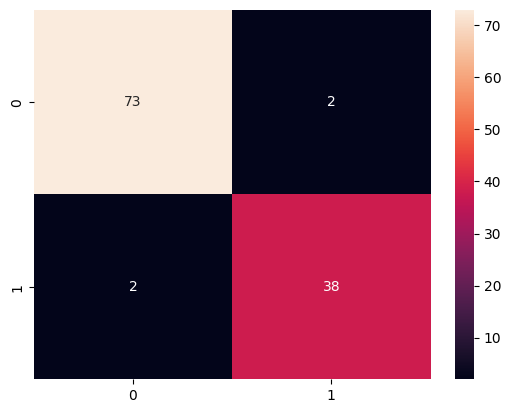

In [83]:
# Confusion Matrix via Heat Map

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot = True, fmt = 'g')

In [84]:
# Classification Report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           B       0.97      0.97      0.97        75
           M       0.95      0.95      0.95        40

    accuracy                           0.97       115
   macro avg       0.96      0.96      0.96       115
weighted avg       0.97      0.97      0.97       115

